In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [11]:
df = pd.read_csv("../data/processed/cleaned_tickets.csv")

sns.set(style="whitegrid")

In [13]:
scaler = MinMaxScaler()

In [14]:
df["resolution_scaled"] = scaler.fit_transform(
    df[["resolution_time_hours"]]
)

df["response_delay_scaled"] = scaler.fit_transform(
    df[["response_delay_hours"]].fillna(0)
)

df["effort_scaled"] = scaler.fit_transform(
    df[["customer_effort_score"]]
)

df["satisfaction_scaled"] = scaler.fit_transform(
    df[["customer_satisfaction_rating"]]
)

In [15]:
df["friction_score"] = (
    df["resolution_scaled"]
    + df["response_delay_scaled"]
    + df["effort_scaled"]
    + (1 - df["satisfaction_scaled"])
) / 4

In [16]:
ticket_type_friction = (
    df.groupby("ticket_type_grouped")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_friction=("friction_score", "mean"),
        avg_resolution=("resolution_time_hours", "mean"),
        avg_satisfaction=("customer_satisfaction_rating", "mean"),
        delay_rate=("is_delayed", "mean")
    )
    .sort_values(by="avg_friction", ascending=False)
)

ticket_type_friction

,ticket_count,avg_friction,avg_resolution,avg_satisfaction,delay_rate
ticket_type_grouped,,,,,
Refund request,304,0.427688,8.117818,2.898026,0.286184
Technical issue,305,0.404328,7.365191,2.891803,0.249180
Product inquiry,257,0.403557,7.676070,3.136187,0.249027
Cancellation request,265,0.402026,7.693082,3.120755,0.252830
Billing inquiry,273,0.384901,7.010256,3.135531,0.208791


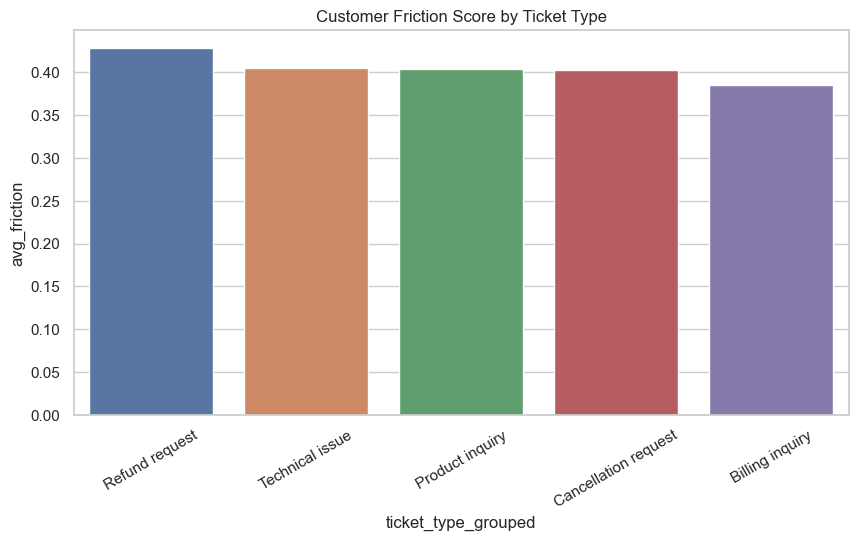

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=ticket_type_friction.reset_index(),
    x="ticket_type_grouped",
    y="avg_friction"
)

plt.title("Customer Friction Score by Ticket Type")
plt.xticks(rotation=30)
plt.show()

In [19]:
channel_friction = (
    df.groupby("ticket_channel")
    .agg(
        ticket_count=("ticket_id","count"),
        avg_friction=("friction_score","mean"),
        avg_resolution=("resolution_time_hours","mean"),
        avg_satisfaction=("customer_satisfaction_rating","mean")
    )
    .sort_values(by="avg_friction", ascending=False)
)

channel_friction

,ticket_count,avg_friction,avg_resolution,avg_satisfaction
ticket_channel,,,,
Email,374,0.415481,7.617781,2.965241
Phone,327,0.408823,7.264118,2.923547
Social media,348,0.405428,7.911734,3.034483
Chat,355,0.390149,7.497793,3.185915


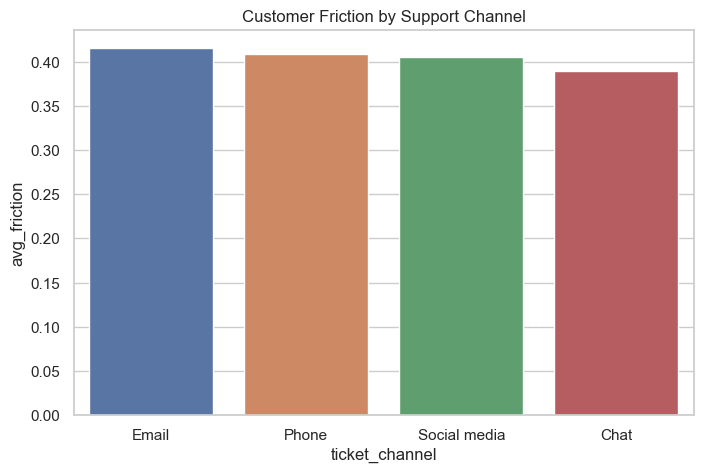

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=channel_friction.reset_index(),
    x="ticket_channel",
    y="avg_friction"
)

plt.title("Customer Friction by Support Channel")
plt.show()

In [21]:
priority_friction = (
    df.groupby("ticket_priority")
    .agg(
        ticket_count=("ticket_id","count"),
        avg_resolution=("resolution_time_hours","mean"),
        avg_satisfaction=("customer_satisfaction_rating","mean"),
        avg_friction=("friction_score","mean")
    )
)

priority_friction

,ticket_count,avg_resolution,avg_satisfaction,avg_friction
ticket_priority,,,,
Critical,374,7.147014,2.997326,0.397202
High,355,8.074836,3.014085,0.419160
Low,334,7.947405,3.074850,0.406897
Medium,341,7.171359,3.032258,0.397091


In [22]:
effort_analysis = (
    df.groupby("high_effort")
    .agg(
        ticket_count=("ticket_id","count"),
        avg_resolution=("resolution_time_hours","mean"),
        avg_satisfaction=("customer_satisfaction_rating","mean"),
        avg_friction=("friction_score","mean")
    )
)

effort_analysis

,ticket_count,avg_resolution,avg_satisfaction,avg_friction
high_effort,,,,
False,1053,4.878759,3.046534,0.335054
True,351,15.675451,2.974359,0.614970


In [23]:
top_products = df["product_purchased"].value_counts().head(8).index

product_friction = (
    df[df["product_purchased"].isin(top_products)]
    .groupby("product_purchased")
    .agg(
        avg_resolution=("resolution_time_hours","mean"),
        avg_satisfaction=("customer_satisfaction_rating","mean"),
        avg_friction=("friction_score","mean")
    )
    .sort_values(by="avg_friction", ascending=False)
)

product_friction

,avg_resolution,avg_satisfaction,avg_friction
product_purchased,,,
Sony 4K HDR TV,7.278632,2.615385,0.449227
Sony Xperia,7.752083,2.950000,0.421395
Nest Thermostat,8.170370,3.200000,0.414397
GoPro Hero,8.114683,3.476190,0.403001
Canon EOS,7.133333,3.046512,0.400155
Amazon Echo,7.509470,3.045455,0.397950
iPhone,6.955039,2.953488,0.394452
Microsoft Office,6.214530,3.051282,0.376048


In [24]:
segment_friction = (
    df.groupby("customer_gender")
    .agg(
        avg_resolution=("resolution_time_hours","mean"),
        avg_satisfaction=("customer_satisfaction_rating","mean"),
        avg_friction=("friction_score","mean")
    )
)

segment_friction

,avg_resolution,avg_satisfaction,avg_friction
customer_gender,,,
Female,7.292285,3.018036,0.401872
Male,7.505809,3.062241,0.400012
Other,7.997084,3.002364,0.414484


In [25]:
friction_corr = df[
    [
        "resolution_time_hours",
        "response_delay_hours",
        "customer_effort_score",
        "priority_score",
        "description_length",
        "friction_score"
    ]
].corr()

friction_corr["friction_score"].sort_values(ascending=False)

friction_score           1.000000
customer_effort_score    0.759854
resolution_time_hours    0.748427
response_delay_hours     0.413974
priority_score          -0.005398
description_length      -0.016832
Name: friction_score, dtype: float64

In [26]:
priority_matrix = (
    df.groupby("ticket_type_grouped")
    .agg(
        avg_friction=("friction_score","mean"),
        ticket_volume=("ticket_id","count")
    )
)

priority_matrix

,avg_friction,ticket_volume
ticket_type_grouped,,
Billing inquiry,0.384901,273
Cancellation request,0.402026,265
Product inquiry,0.403557,257
Refund request,0.427688,304
Technical issue,0.404328,305


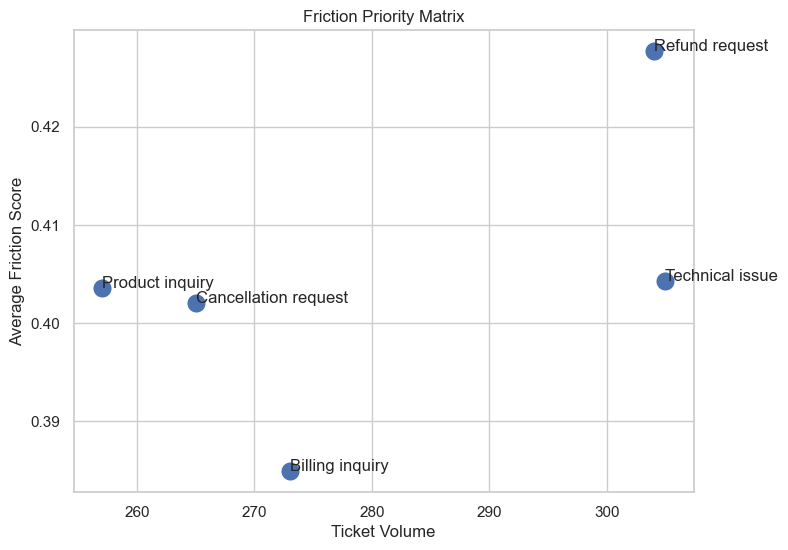

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=priority_matrix.reset_index(),
    x="ticket_volume",
    y="avg_friction",
    s=200
)

plt.title("Friction Priority Matrix")
plt.xlabel("Ticket Volume")
plt.ylabel("Average Friction Score")

for i,row in priority_matrix.reset_index().iterrows():
    plt.text(row.ticket_volume,row.avg_friction,row.ticket_type_grouped)

plt.show()